# Interaction of Two KdV Solitons

This program propagates two initially separated solitons of the Korteweg–De Vries equation, which interact and then separate again. The phase shift compared to undisturbed propagation of individual solitons is extracted.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Functions

### Analytical Soliton Solution

The analytical solution of a KdV soliton at a fixed time $t$ is:

$$
y(x,t) = \frac{c}{2} \; \text{sech}^2\left(\frac{\sqrt{c}}{2}(x-x_0-ct)\right)
$$

In [2]:
def sech(x):
    return 1/np.cosh(x)

def KdVSoliton(x, t, c, x0, NG):
    y = 0.5 * c * sech(0.5 * np.sqrt(c) * (x[:NG] - x0 - c * t))**2
    return y

## Parameters

In [3]:
L = 80                               # Length of the water line

NG = 801                             # Number of spatial grid points
dx = L/(NG-1)                        # Distance between two grid points
x = np.arange(NG)*dx                

Tmax = 30.                            # Maximum time
NT = 100001                           # Number of time steps
dt = Tmax/(NT-1)                      # Time step
t = np.arange(NT)*dt                  # Time grid

## Prepare Grid

In [4]:
ys = np.zeros((NT, NG))

# Integration of the solution",
Two initially separated solitons move with different velocities to the right. The left soliton is faster, so after some time they overlap.

## Initial Condition: Two Separated Solitons

In [7]:
# Initial condition: two solitons with velocities c1 and c2
c1  = 2.0
x01 = 10
c2 = 1.0
x02 = 20
ys[0,:] = KdVSoliton(x,0,c1,x01,NG) + KdVSoliton(x,0,c2,x02,NG)

# Second time step required for symmetric discrete derivative form
# Soliton has advanced by dt with velocity c
ys[1,:] = KdVSoliton(x,dt,c1,x01,NG) + KdVSoliton(x,dt,c2,x02,NG) 

## Solve the KdV PDE using Finite Difference Method

The discretized update scheme:

$$
y_x = y_{i+1}-y_{i-1}, \quad y_{xxx} = y_{i+2}-2y_{i+1}+2y_{i-1}-y_{i-2}
$$
$$
y_j = y_{j-2} - \frac{dt}{dx} \left(6 y_{j-1} y_x + \frac{y_{xxx}}{dx^2} \right)
$$

In [9]:
# Solve the PDE using the finite-difference method
for j in range(2, NT):
    
    yx  = ys[j-1, 3:NG-1] - ys[j-1, 1:NG-3]
    
    yx3 = (
        ys[j-1, 4:NG] 
        - 2*ys[j-1, 3:NG-1] 
        + 2*ys[j-1, 1:NG-3] 
        - ys[j-1, 0:NG-4])
    
    ys[j, 2:NG-2] = ys[j-2, 2:NG-2] - (dt/dx)*(6*ys[j-1, 2:NG-2]*yx + yx3/dx**2)

## Extract Maxima of Solitons at Selected Times

In [11]:
# extract both maxima for t(66666) (python starts with 0)
nmax = 0
x_maxima1 = []
for i in range(1, NG-1):
    if ys[66665,i] > ys[66665,i-1] and ys[66665,i] > ys[66665,i+1] and ys[69999,i] > 0.1:
        x_maxima1.append(x[i])
        nmax += 1

# extract both maxima for t(NT)
nmax = 0
x_maxima2 = []
for i in range(1, NG-1):
    if ys[NT-1,i] > ys[NT-1,i-1] and ys[NT-1,i] > ys[NT-1,i+1] and ys[NT-1,i] > 0.1:
        x_maxima2.append(x[i])
        nmax += 1

## Visualization

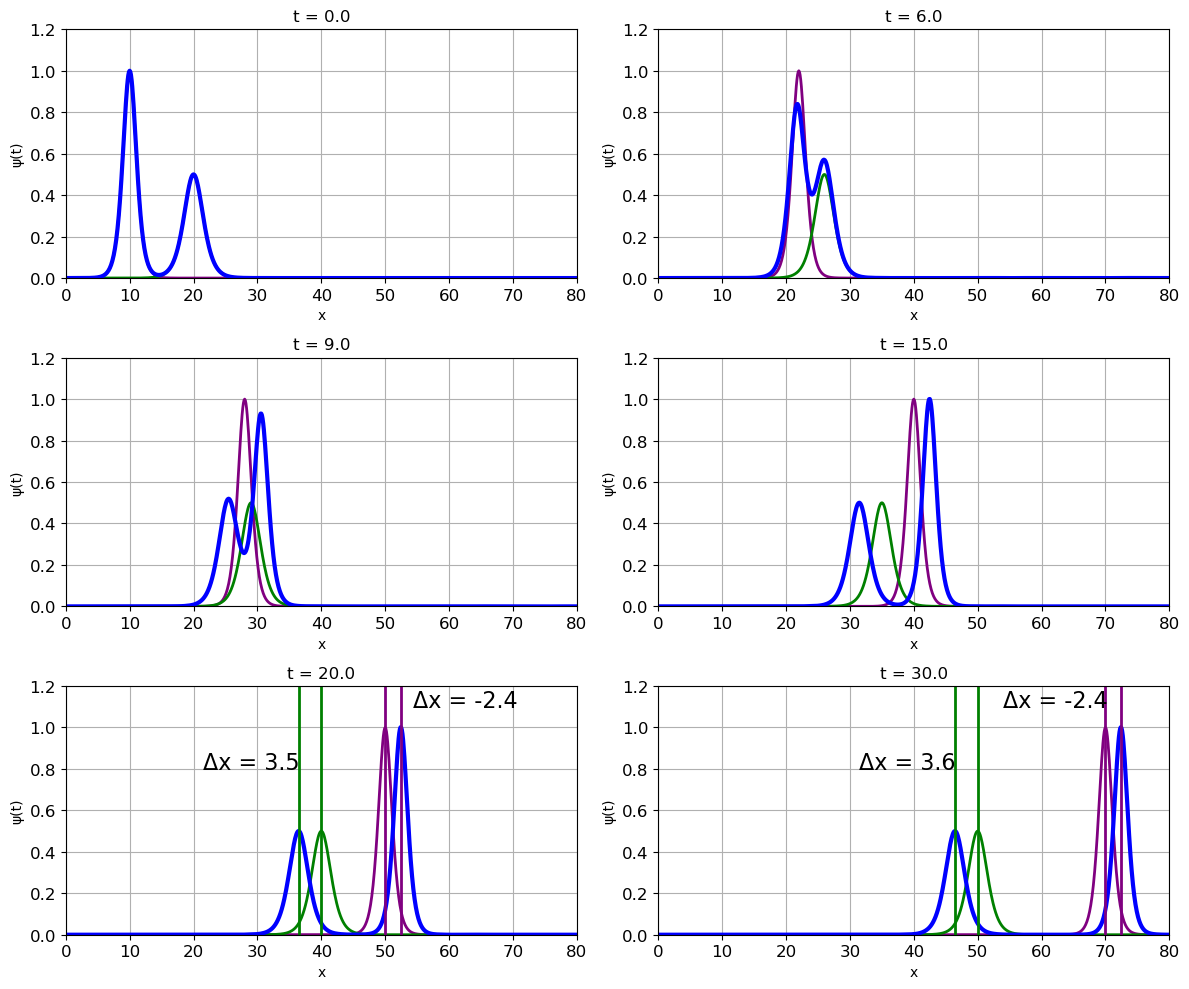

In [16]:
k = [0, 19999, 29999, 49999, 66665, 100000]  

Colors = ['purple','green','blue']

plt.figure(figsize=(12,10))
for idx, ki in enumerate(k):
    plt.subplot(3,2,idx+1)
    plt.plot(x, KdVSoliton(x, dt*ki, c1, x01, NG), linewidth=2, color=Colors[0])
    plt.plot(x, KdVSoliton(x, dt*ki, c2, x02, NG), linewidth=2, color=Colors[1])
    plt.plot(x, ys[ki,:], linewidth=3, color=Colors[2])
    
    # Add phase shift lines and labels for t = 66666
    if ki == 66665:
        plt.axvline(x_maxima1[0], linewidth=2, color=Colors[1])
        plt.axvline(x02 + c2*t[ki], linewidth=2, color=Colors[1])
        plt.text(x_maxima1[0]-15,0.8,f'Δx = {x02 + c2*t[ki] - x_maxima1[0]:.1f}', fontsize=16)
        plt.axvline(x_maxima1[1], linewidth=2, color=Colors[0])
        plt.axvline(x01 + c1*t[ki], linewidth=2, color=Colors[0])
        plt.text(x_maxima1[1]+2,1.1,f'Δx = {x01 + c1*t[ki] - x_maxima1[1]:.1f}', fontsize=16)
    # Add phase shift lines and labels for t = NT
    if ki == NT-1:
        plt.axvline(x_maxima2[0], linewidth=2, color=Colors[1])
        plt.axvline(x02 + c2*t[ki], linewidth=2, color=Colors[1])
        plt.text(x_maxima2[0]-15,0.8,f'Δx = {x02 + c2*t[ki] - x_maxima2[0]:.1f}', fontsize=16)
        plt.axvline(x_maxima2[1], linewidth=2, color=Colors[0])
        plt.axvline(x01 + c1*t[ki], linewidth=2, color=Colors[0])
        plt.text(x01 + c1*t[ki]-16,1.1,f'Δx = {x01 + c1*t[ki] - x_maxima2[1]:.1f}', fontsize=16)
    
    plt.grid(True)
    plt.axis([np.min(x), np.max(x), 0, 1.2])
    plt.xlabel('x')
    plt.ylabel('ψ(t)')
    plt.title(f't = {t[ki]:.1f}')
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()